<a href="https://colab.research.google.com/github/deekshasoota/ML-lab-project/blob/main/lab%20practical.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [12]:
import kagglehub
import pandas as pd # Ensure pandas is imported for pd.read_csv
from kagglehub import KaggleDatasetAdapter # Re-import KaggleDatasetAdapter

file_path = "train_u6lujuX_CVtuZ9i.csv" # Corrected filename based on dataset listing

# Use dataset_load() to load the DataFrame directly
df = kagglehub.dataset_load(
  adapter=KaggleDatasetAdapter.PANDAS, # Add the adapter argument
  handle="altruistdelhite04/loan-prediction-problem-dataset", # Explicitly passing handle as a keyword argument
  path=file_path # The path for the specific file within the dataset
)

print("First 5 records:", df.head())

Using Colab cache for faster access to the 'loan-prediction-problem-dataset' dataset.
First 5 records:     Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History Property_Area Loan_Status  
0        

In [8]:
import os

dataset_root_path = '/kaggle/input/loan-prediction-problem-dataset'
print(f"Files in {dataset_root_path}:")
for dirname, _, filenames in os.walk(dataset_root_path):
    for filename in filenames:
        print(os.path.join(dirname, filename))

Files in /kaggle/input/loan-prediction-problem-dataset:
/kaggle/input/loan-prediction-problem-dataset/test_Y3wMUE5_7gLdaTN.csv
/kaggle/input/loan-prediction-problem-dataset/train_u6lujuX_CVtuZ9i.csv


In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix

In [15]:
df.ffill(inplace=True)

le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

In [14]:
# Example: Loading an uploaded CSV file
import pandas as pd

# Replace 'your_file_name.csv' with the actual name of your uploaded file
# For example, if you uploaded 'my_data.csv', use 'my_data.csv'
try:
    df_uploaded = pd.read_csv('loan_prediction.csv')
    print("Successfully loaded 'loan_prediction.csv'!")
    print("First 5 rows of the uploaded data:")
    print(df_uploaded.head())
except FileNotFoundError:
    print("Error: The file 'your_file_name.csv' was not found. Please ensure you have uploaded it and the name is correct.")
except Exception as e:
    print(f"An error occurred while loading the file: {e}")

Error: The file 'your_file_name.csv' was not found. Please ensure you have uploaded it and the name is correct.


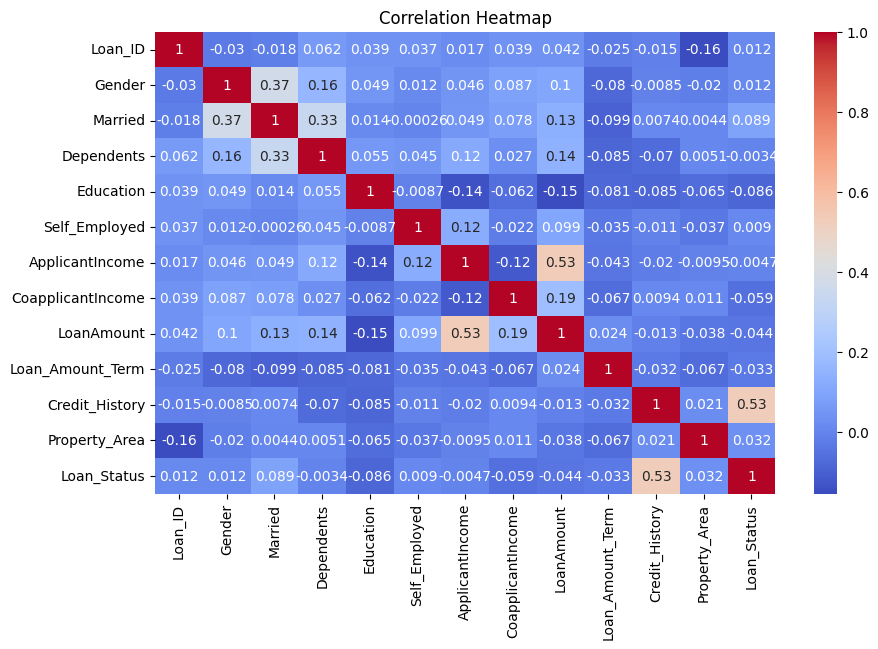

In [16]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

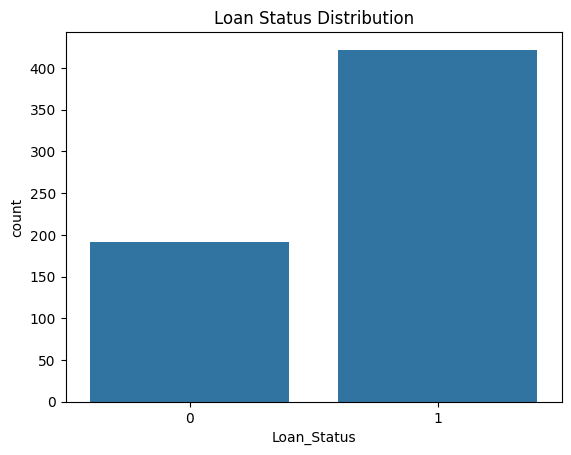

In [17]:
sns.countplot(x='Loan_Status', data=df)
plt.title("Loan Status Distribution")
plt.show()

In [18]:

X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)



In [22]:

model = DecisionTreeClassifier()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [23]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

Accuracy: 0.7235772357723578
Confusion Matrix:
 [[26 17]
 [17 63]]


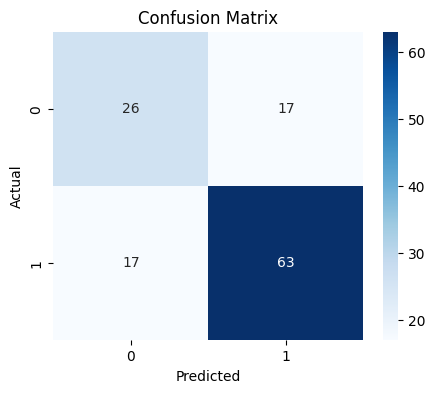

In [24]:
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [25]:
print("Classification Report:\n", classification_report(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.60      0.60      0.60        43
           1       0.79      0.79      0.79        80

    accuracy                           0.72       123
   macro avg       0.70      0.70      0.70       123
weighted avg       0.72      0.72      0.72       123

